# DINO candidates → SAM3 point prompts → tracking

Bridge between the two backbones for the main research goal: `run_zoom_detector`
proposes object points (deepest-wins merge, normalized to the original frame),
each surviving detection becomes a SAM3 tracker point prompt (one `obj_id` per
detection), and SAM3 propagates the resulting masklets through the video.

Prompt selection: `min_confirmations=2` keeps only detections confirmed at more
than one zoom level; `score_mean`, `solidity` and `area` rank the rest. Point
prompts cannot be mixed with a text prompt in the same call, so this notebook
tracks whatever DINO proposed — not only dolphins.

Session order: `start_session` → `add_prompt` (points) → `propagate_in_video` →
`close_session` → `predictor.shutdown()`. The SAM3 checkpoint auto-downloads from
the gated `facebook/sam3`/`facebook/sam3.1` repos: `load_env()` must find
`HF_TOKEN`.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch

from fish_segmentation.dinov3 import load_backbone, run_zoom_detector
from fish_segmentation.ingest import process_video
from fish_segmentation.paths import find_repo_root, load_env
from fish_segmentation.video_io import load_all_frames_rgb, load_sampled_frames

load_env()
ROOT = find_repo_root()

device = "cuda" if torch.cuda.is_available() else "cpu"
DINO_LONG_SIDE = 1024
DINO_RESOLUTION_SCALE = 4.0
ZONE_MERGE_GAP = 0.08
MIN_ZONE_FRACTION = 0.25
MIN_CONFIRMATIONS = 2   # keep only detections confirmed at >= 2 zoom levels
PROMPT_FRAME = 0
print(device)


cuda


## 1. DINO candidates on the prompt frame

Same detector as `03_dinov3_detect.ipynb`, but the merged detections are read as
prompts: `x`/`y` are relative `[0, 1]` of the original frame (the convention SAM3
expects) and `bbox` is the normalized tight box of the deepest region.


In [2]:
video_path = ROOT / "dataset" / "processed" / "20260813_213529_7f994a2f" / "video.mp4"
if not video_path.exists():
    video_path = ROOT / "data" / "test_media" / "dolphin_00.mp4"
print(f"Using video: {video_path}")

frames = load_sampled_frames(video_path=str(video_path), n_frames=PROMPT_FRAME + 1)
prompt_frame = frames[PROMPT_FRAME]
video_frames_for_vis = load_all_frames_rgb(str(video_path))
print(f"Prompt frame: {prompt_frame.size[0]}x{prompt_frame.size[1]}, "
      f"{len(video_frames_for_vis)} frames to track")

# SAM3 runs at ~1008 px internally but caches per-frame masks at the session
# video resolution (4 objects x 475 frames at 4K ~ 15 GB VRAM -> OOM on a
# 24 GB card). Track on a 1024x576 proxy instead: prompt points are relative,
# so they carry over unchanged, and the overlay video keeps the full-res frames.
OUTPUTS = ROOT / "notebooks" / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)
sam3_video_path = OUTPUTS / f"{video_path.parent.name}_{video_path.stem}_1024x576.mp4"
if not sam3_video_path.exists():
    process_video(
        input_path=str(video_path),
        output_path=str(sam3_video_path),
        target_width=1024,
        target_height=576,
        fps=15,
    )
print(f"SAM3 session video: {sam3_video_path}")


Using video: /workspace/fish-segmentation/dataset/processed/20260813_213529_7f994a2f/video.mp4


Prompt frame: 3840x2160, 475 frames to track


ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

[libx264 @ 0x5dad291ed0c0] using cpu capabilities: MMX2 SSE2Fast SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2
[libx264 @ 0x5dad291ed0c0] profile High, level 3.1, 4:2:0, 8-bit
[libx264 @ 0x5dad291ed0c0] 264 - core 164 r3108 31e19f9 - H.264/MPEG-4 AVC codec - Copyleft 2003-2023 - http://www.videolan.org/x264.html - options: cabac=1 ref=3 deblock=1:0:0 analyse=0x3:0x113 me=hex subme=7 psy=1 psy_rd=1.00:0.00 mixed_ref=1 me_range=16 chroma_me=1 trellis=1 8x8dct=1 cqm=0 deadzone=21,11 fast_pskip=1 chroma_qp_offset=-2 threads=18 lookahead_threads=3 sliced_threads=0 nr=0 decimate=1 interlaced=0 bluray_compat=0 constrained_intra=0 bframes=3 b_pyramid=2 b_adapt=1 b_bias=0 direct=1 weightb=1 open_gop=0 weightp=2 keyint=250 keyint_min=15 scenecut=40 intra_refresh=0 rc_lookahead=40 rc=crf mbtree=1 crf=18.0 qcomp=0.60 qpmin=0 qpmax=69 qpstep=4 ip_ratio=1.40 aq=1:1.00
Output #0, mp4, to '/workspace/fish-segmentation/notebooks/outputs/20260813_213529_7f994a2f_video_1024x576.mp4':
  Metadata:
    major_brand     : 

SAM3 session video: /workspace/fish-segmentation/notebooks/outputs/20260813_213529_7f994a2f_video_1024x576.mp4


[out#0/mp4 @ 0x5dad291ebf80] video:5887kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.058669%
frame=  475 fps=127 q=-1.0 Lsize=    5891kB time=00:00:31.46 bitrate=1533.6kbits/s speed=8.43x    
[libx264 @ 0x5dad291ed0c0] frame I:4     Avg QP:11.73  size: 30630
[libx264 @ 0x5dad291ed0c0] frame P:413   Avg QP:14.10  size: 13057
[libx264 @ 0x5dad291ed0c0] frame B:58    Avg QP:14.40  size:  8840
[libx264 @ 0x5dad291ed0c0] consecutive B-frames: 83.6%  0.4%  0.0% 16.0%
[libx264 @ 0x5dad291ed0c0] mb I  I16..4:  6.4% 73.7% 19.9%
[libx264 @ 0x5dad291ed0c0] mb P  I16..4:  0.4%  1.6%  0.4%  P16..4: 48.7% 33.4% 13.1%  0.0%  0.0%    skip: 2.3%
[libx264 @ 0x5dad291ed0c0] mb B  I16..4:  0.2%  0.3%  0.0%  B16..8: 49.8% 10.1%  1.3%  direct:14.1%  skip:24.1%  L0:43.1% L1:52.6% BI: 4.3%
[libx264 @ 0x5dad291ed0c0] 8x8 transform intra:68.6% inter:80.2%
[libx264 @ 0x5dad291ed0c0] coded y,uvDC,uvAC intra: 48.8% 92.4% 77.9% inter: 32.5% 65.6% 21.3%
[libx264 @ 0x5dad291ed0c0] 

In [3]:
model, processor = load_backbone("facebook/dinov3-vitl16-pretrain-lvd1689m", device=device)


Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

In [4]:
detections = run_zoom_detector(
    image=prompt_frame,
    model=model,
    processor=processor,
    long_side=DINO_LONG_SIDE,
    resolution_scale=DINO_RESOLUTION_SCALE,
    merge_gap=ZONE_MERGE_GAP,
    min_zone_fraction=MIN_ZONE_FRACTION,
    min_confirmations=MIN_CONFIRMATIONS,
)
print(f"{len(detections)} DINO candidates")
for k, det in enumerate(detections):
    print(
        f"obj {k}: L{det['level']} n_levels={det['n_levels']} "
        f"xy=({det['x']:.3f}, {det['y']:.3f}) r={det['radius']:.4f} "
        f"score={det['score_mean']:.3f} solidity={det['solidity']:.2f} "
        f"bbox={tuple(round(v, 3) for v in det['bbox'])}"
    )


4 DINO candidates
obj 0: L1 n_levels=2 xy=(0.453, 0.584) r=0.0022 score=0.746 solidity=11.73 bbox=(0.434, 0.564, 0.463, 0.615)
obj 1: L1 n_levels=2 xy=(0.423, 0.586) r=0.0043 score=0.760 solidity=3.85 bbox=(0.418, 0.533, 0.436, 0.606)
obj 2: L1 n_levels=2 xy=(0.437, 0.634) r=0.0042 score=0.825 solidity=2.35 bbox=(0.431, 0.62, 0.445, 0.653)
obj 3: L1 n_levels=2 xy=(0.472, 0.667) r=0.0076 score=0.803 solidity=3.35 bbox=(0.459, 0.63, 0.49, 0.689)


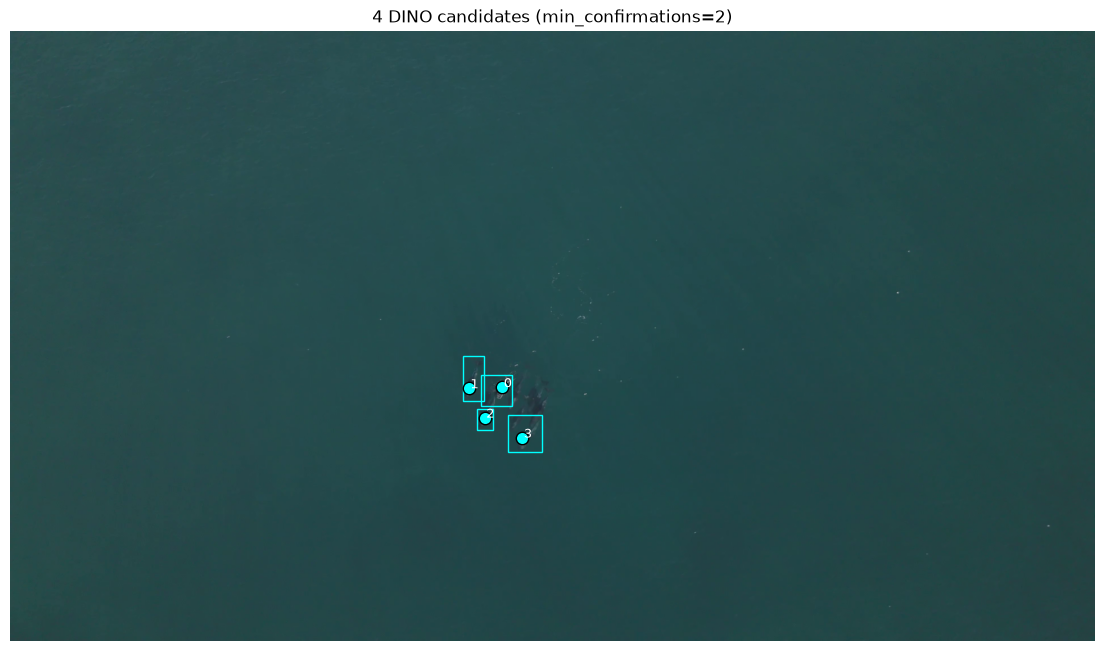

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
W, H = prompt_frame.size
ax.imshow(prompt_frame)
for k, det in enumerate(detections):
    cx, cy = det["x"] * W, det["y"] * H
    ax.scatter(cx, cy, c="cyan", edgecolors="black", s=80, zorder=5)
    ax.annotate(str(k), (cx + 6, cy), color="white", fontsize=9, zorder=6)
    bx0, by0, bx1, by1 = det["bbox"]
    ax.add_patch(
        plt.Rectangle(
            (bx0 * W, by0 * H),
            (bx1 - bx0) * W,
            (by1 - by0) * H,
            fill=False,
            edgecolor="cyan",
            linewidth=1.0,
        )
    )
ax.set_title(f"{len(detections)} DINO candidates (min_confirmations={MIN_CONFIRMATIONS})")
ax.axis("off")
plt.show()


## 2. SAM3: one point prompt per candidate

`add_point_prompt` wraps the `add_prompt` request: `points=[[x, y]]` with
`rel_coordinates=True` (SAM3 default), a fresh `obj_id` per detection. SAM3 runs
tracker inference immediately and returns the mask of the prompted object on that
frame. Call again with the same `obj_id` to refine an object with more points.


In [6]:
from sam3.model_builder import build_sam3_video_predictor

from fish_segmentation.sam3_utils import add_point_prompt, propagate_in_video

predictor = build_sam3_video_predictor(gpus_to_use=range(torch.cuda.device_count()))


/workspace/fish-segmentation/sam3_src/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


/workspace/fish-segmentation/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-09-20 19:33:52,950 13403 sam3_video_predictor.py: 120: using the following GPU IDs: [0]


INFO 2026-09-20 19:33:52,952 13403 sam3_video_predictor.py: 136: 


	*** START loading model on all ranks ***




INFO 2026-09-20 19:33:52,952 13403 sam3_video_predictor.py: 138: loading model on rank=0 with world_size=1 -- this could take a while ...


INFO 2026-09-20 19:34:00,942 13403 sam3_video_base.py: 354: setting max_num_objects=10000 and num_obj_for_compile=16


INFO 2026-09-20 19:34:15,290 13403 sam3_video_predictor.py: 140: loading model on rank=0 with world_size=1 -- DONE locally


INFO 2026-09-20 19:34:15,291 13403 sam3_video_predictor.py: 151: 


	*** DONE loading model on all ranks ***




In [7]:
response = predictor.handle_request(
    request=dict(
        type="start_session",
        resource_path=str(sam3_video_path),
    )
)
session_id = response["session_id"]


frame loading (OpenCV) [rank=0]:   0%|          | 0/475 [00:00<?, ?it/s]

frame loading (OpenCV) [rank=0]:   4%|▍         | 21/475 [00:00<00:02, 208.80it/s]

frame loading (OpenCV) [rank=0]:  28%|██▊       | 135/475 [00:00<00:00, 750.85it/s]

frame loading (OpenCV) [rank=0]:  51%|█████     | 241/475 [00:00<00:00, 888.75it/s]

frame loading (OpenCV) [rank=0]:  76%|███████▌  | 359/475 [00:00<00:00, 1002.92it/s]

frame loading (OpenCV) [rank=0]:  98%|█████████▊| 465/475 [00:00<00:00, 1022.66it/s]

frame loading (OpenCV) [rank=0]: 100%|██████████| 475/475 [00:00<00:00, 927.26it/s] 

INFO 2026-09-20 19:34:17,196 13403 sam3_base_predictor.py: 146: started new session 800ecbdc-f565-4455-b6b6-e61f32cd5ce1


In [8]:
# one obj_id per DINO detection; detections are already relative [0, 1]
outputs = None
for obj_id, det in enumerate(detections):
    outputs = add_point_prompt(
        predictor,
        session_id,
        frame_index=PROMPT_FRAME,
        points=[[det["x"], det["y"]]],
        obj_id=obj_id,
    )
print(f"{len(detections)} point prompts added on frame {PROMPT_FRAME}")


4 point prompts added on frame 0


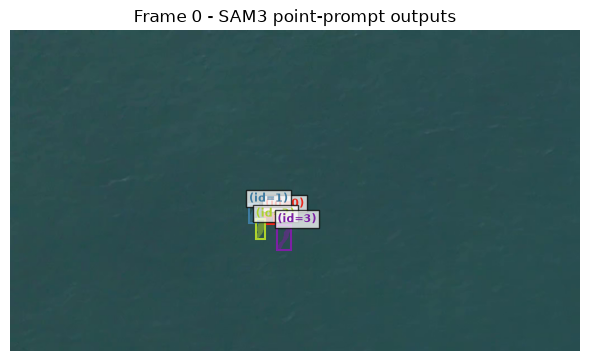

In [9]:
from sam3.visualization_utils import (
    prepare_masks_for_visualization,
    save_masklet_video,
    visualize_formatted_frame_output,
)

plt.close("all")
visualize_formatted_frame_output(
    PROMPT_FRAME,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({PROMPT_FRAME: outputs})],
    titles=["SAM3 point-prompt outputs"],
    figsize=(6, 4),
)


## 3. Propagate the masklets through the video

Every prompted `obj_id` is tracked to the end of the video; the overlay video
makes it easy to check which candidates became stable dolphin tracks.


In [10]:
outputs_per_frame = propagate_in_video(predictor, session_id, start_frame_index=PROMPT_FRAME)

OUTPUTS = ROOT / "notebooks" / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)
save_masklet_video(
    video_frames=video_frames_for_vis,
    outputs=outputs_per_frame,
    out_path=str(OUTPUTS / "dino_prompt_tracking_20260813_213529.mp4"),
    alpha=0.5,
    fps=15,
)


  0%|          | 0/475 [00:00<?, ?it/s]

0it [00:00, ?it/s]

INFO 2026-09-20 19:35:36,611 13403 sam3_base_predictor.py: 305: propagation ended in session 800ecbdc-f565-4455-b6b6-e61f32cd5ce1


  0%|          | 0/475 [00:00<?, ?it/s]

  0%|          | 1/475 [00:00<00:49,  9.65it/s]

...

100%|██████████| 475/475 [00:43<00:00, 10.89it/s]

ffmpeg version 6.1.1-3ubuntu5 Copyright (c) 2000-2023 the FFmpeg developers
  built with gcc 13 (Ubuntu 13.2.0-23ubuntu3)
  configuration: --prefix=/usr --extra-version=3ubuntu5 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --disable-omx --enable-gnutls --enable-libaom --enable-libass --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libglslang --enable-libgme --enable-libgsm --enable-libharfbuzz --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx265 --enable-libxml2 --enable-libxvid --enable-libzimg --ena

[libx264 @ 0x647de83a1400] using SAR=1/1
[libx264 @ 0x647de83a1400] using cpu capabilities: MMX2 SSE2Fast SSSE3 SSE4.2 AVX FMA3 BMI2 AVX2
[libx264 @ 0x647de83a1400] profile High, level 5.1, 4:2:0, 8-bit
[libx264 @ 0x647de83a1400] 264 - core 164 r3108 31e19f9 - H.264/MPEG-4 AVC codec - Copyleft 2003-2023 - http://www.videolan.org/x264.html - options: cabac=1 ref=3 deblock=1:0:0 analyse=0x3:0x113 me=hex subme=7 psy=1 psy_rd=1.00:0.00 mixed_ref=1 me_range=16 chroma_me=1 trellis=1 8x8dct=1 cqm=0 deadzone=21,11 fast_pskip=1 chroma_qp_offset=-2 threads=67 lookahead_threads=11 sliced_threads=0 nr=0 decimate=1 interlaced=0 bluray_compat=0 constrained_intra=0 bframes=3 b_pyramid=2 b_adapt=1 b_bias=0 direct=1 weightb=1 open_gop=0 weightp=2 keyint=250 keyint_min=15 scenecut=40 intra_refresh=0 rc_lookahead=40 rc=crf mbtree=1 crf=23.0 qcomp=0.60 qpmin=0 qpmax=69 qpstep=4 ip_ratio=1.40 aq=1:1.00
Output #0, mp4, to '/workspace/fish-segmentation/notebooks/outputs/dino_prompt_tracking_20260813_213529.m

Re-encoded video saved to /workspace/fish-segmentation/notebooks/outputs/dino_prompt_tracking_20260813_213529.mp4


[out#0/mp4 @ 0x647de839fa80] video:39635kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.016501%
frame=  475 fps= 44 q=-1.0 Lsize=   39641kB time=00:00:31.46 bitrate=10320.2kbits/s speed=2.94x    
[libx264 @ 0x647de83a1400] frame I:6     Avg QP:13.42  size:112806
[libx264 @ 0x647de83a1400] frame P:133   Avg QP:16.02  size:101814
[libx264 @ 0x647de83a1400] frame B:336   Avg QP:16.53  size: 78474
[libx264 @ 0x647de83a1400] consecutive B-frames:  4.0%  0.4% 13.9% 81.7%
[libx264 @ 0x647de83a1400] mb I  I16..4: 47.3% 52.2%  0.4%
[libx264 @ 0x647de83a1400] mb P  I16..4: 20.8% 42.6%  0.2%  P16..4: 22.3%  4.6%  2.9%  0.0%  0.0%    skip: 6.7%
[libx264 @ 0x647de83a1400] mb B  I16..4:  4.1%  9.3%  0.0%  B16..8: 41.5%  6.8%  0.4%  direct:17.9%  skip:20.0%  L0:60.4% L1:38.5% BI: 1.1%
[libx264 @ 0x647de83a1400] 8x8 transform intra:67.2% inter:80.1%
[libx264 @ 0x647de83a1400] coded y,uvDC,uvAC intra: 17.5% 55.9% 8.8% inter: 7.5% 47.8% 2.3%
[libx264 @ 0x647de83a1400] i

In [11]:
from IPython.display import Video

# relative src so JupyterLab serves it from notebooks/outputs without
# embedding the 4K mp4 in the .ipynb
Video("outputs/dino_prompt_tracking_20260813_213529.mp4", embed=False, width=640)


## 4. Cleanup

`close_session` frees the session; `predictor.shutdown()` frees the process group.


In [12]:
_ = predictor.handle_request(
    request=dict(
        type="close_session",
        session_id=session_id,
    )
)

predictor.shutdown()


INFO 2026-09-20 19:36:31,477 13403 sam3_base_predictor.py: 409: removed session 800ecbdc-f565-4455-b6b6-e61f32cd5ce1
